In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

class EvenNet(nn.Module):
    def __init__(self):
        super(EvenNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # MATHEMATICAL RESTRICTION: 
        # By taking the absolute value, h(x) = h(|x|) = h(-x)
        u = torch.abs(x) 
        return self.layers(u)


x_train = torch.linspace(0, 5, 100).view(-1, 1)
y_train = torch.cos(x_train)


model = EvenNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(500):
    optimizer.zero_grad()
    loss = criterion(model(x_train), y_train)
    loss.backward()
    optimizer.step()


test_val = 3.14
x_pos = torch.tensor([[test_val]])
x_neg = torch.tensor([[-test_val]])

y_pos = model(x_pos).item()
y_neg = model(x_neg).item()

print(f"Prediction for h({test_val}):  {y_pos:.6f}")
print(f"Prediction for h(-{test_val}): {y_neg:.6f}")



Prediction for h(3.14):  -0.916817
Prediction for h(-3.14): -0.916817


Here, we basically passing the absolute value of x, instead of just x. This makes our newtwork restricted to learning only even functions. Since the networks handles only positive numbers, when we input a negative number, it is returning symmetrized version.

In this problem, we are using a 2D radiative convection data from the Well dataset. This data is crated by simulating the governing PDEs. The spatial domain is discritized into 128x384 2D Cartesian points. There are different fields in this data set such as Velocity, density, pressure. All these quantities are function of time. There are 90 time trajectories of these quantaties and in each trajectory, there are 101 time steps. 


The symmetry restriction that i think of for this problem is basially:

F(k.x) = F(x)

The reasonbehind is that the dataset is generated by simulating a PDE. In differential equations, we can always take k out and treat it just like a constant.



For this problem, I used the documents and codes in the tutorial section of The Well on Github.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange

In [5]:
!pip install the_well

In [6]:
base_path = "./datasets"


In [7]:
from the_well.data import WellDataset
from the_well.utils.download import well_download

In [8]:
well_download(base_path=base_path, dataset="turbulent_radiative_layer_2D", split="train")

** Resuming transfer from byte position 576
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0    648      0 --:--:-- --:--:-- --:--:--   650
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   197  100   197    0     0    784      0 --:--:-- --:--:-- --:--:--   784
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2371      0 --:--:-- --:--:-- --:--:--  2402
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2355      0 --:--:-- --:--:-- --:--:--  2373
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2390      0 --:--:-- --:--:-- --:--:--  2402
** Resuming transfer from byte position 635467072
  % Total 

In [9]:
well_download(base_path=base_path, dataset="turbulent_radiative_layer_2D", split="valid")

** Resuming transfer from byte position 576
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0    755      0 --:--:-- --:--:-- --:--:--   757
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   197  100   197    0     0    749      0 --:--:-- --:--:-- --:--:--   751
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2117      0 --:--:-- --:--:-- --:--:--  2141
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2297      0 --:--:-- --:--:-- --:--:--  2317
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2295      0 --:--:-- --:--:-- --:--:--  2317
** Resuming transfer from byte position 79459648
  % Total    %

In [10]:
dataset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
)

In [11]:
F = dataset.metadata.n_fields
field_names = [
    name for group in dataset.metadata.field_names.values() for name in group
]
field_names

['density', 'pressure', 'velocity_x', 'velocity_y']

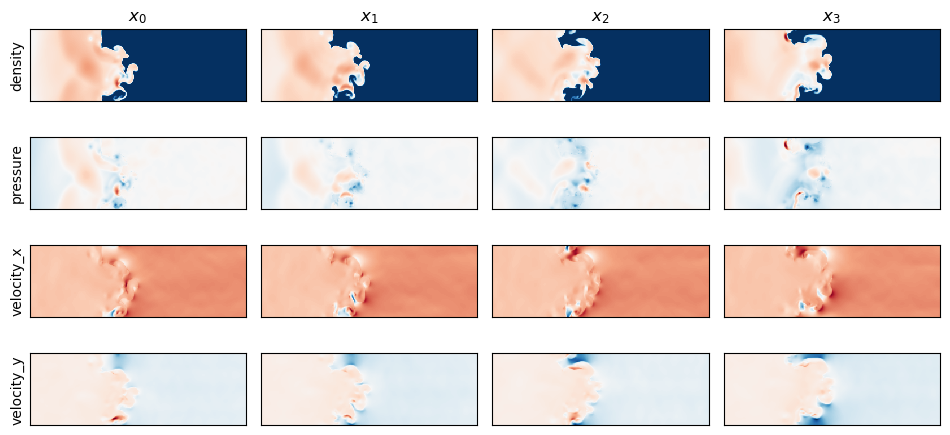

In [12]:
x = dataset[42]["input_fields"]
x = rearrange(x, "T Lx Ly F -> F T Lx Ly")

fig, axs = plt.subplots(F, 4, figsize=(4 * 2.4, F * 1.2))

for field in range(F):
    vmin = np.nanmin(x[field])
    vmax = np.nanmax(x[field])

    axs[field, 0].set_ylabel(f"{field_names[field]}")

    for t in range(4):
        axs[field, t].imshow(
            x[field, t], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax
        )
        axs[field, t].set_xticks([])
        axs[field, t].set_yticks([])

        axs[0, t].set_title(f"$x_{t}$")

plt.tight_layout()

In [2]:
!pip install neuraloperator


In [16]:
from neuralop.models import FNO
from tqdm import tqdm
device = "cuda"

In [17]:
model = FNO(
    n_modes=(16, 16),
    in_channels=4 * F,
    out_channels=1 * F,
    hidden_channels=128,
    n_layers=5,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

AssertionError: Torch not compiled with CUDA enabled